# Clustering by MFCC profile

Clustering all 450 clips by their MFCC feature vector (KMeans and a
Gaussian mixture), no label involved, then checking how well the
clusters recover the real 10 classes.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/model_matrix.pkl', 'rb') as f:
    d = pickle.load(f)
X_mfcc, y, classes = d['X_mfcc'], d['y'], d['classes']
X_mfcc.shape

(450, 120)

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_scaled = StandardScaler().fit_transform(X_mfcc)
pca = PCA(n_components = 20, random_state = 42)
X_pca = pca.fit_transform(X_scaled)
print(f'20 components explain {pca.explained_variance_ratio_.sum():.1%} of variance')

20 components explain 77.2% of variance


In [3]:
K = 10
kmeans = KMeans(n_clusters = K, n_init = 10, random_state = 42)
kmeans_labels = kmeans.fit_predict(X_pca)

gmm = GaussianMixture(n_components = K, covariance_type = 'diag', reg_covar = 1e-3,
                       random_state = 42, n_init = 3)
gmm_labels = gmm.fit_predict(X_pca)

print('KMeans silhouette:', silhouette_score(X_pca, kmeans_labels))
print('KMeans vs true labels (ARI):', adjusted_rand_score(y, kmeans_labels))
print('GMM vs true labels (ARI):', adjusted_rand_score(y, gmm_labels))
print('KMeans vs GMM (ARI):', adjusted_rand_score(kmeans_labels, gmm_labels))

KMeans silhouette: 0.11302100121974945
KMeans vs true labels (ARI): 0.1003174519085559
GMM vs true labels (ARI): 0.11316941388524981
KMeans vs GMM (ARI): 0.2856136146280675


In [4]:
contingency = pd.crosstab(pd.Series(kmeans_labels, name = 'cluster'),
                           pd.Series(y, name = 'true').map(dict(enumerate(classes))))
purity = contingency.div(contingency.sum(axis = 1), axis = 0)
pd.DataFrame({'dominant_class': purity.idxmax(axis = 1), 'share': purity.max(axis = 1).round(2),
              'cluster_size': contingency.sum(axis = 1)})

,dominant_class,share,cluster_size
cluster,,,
0,engine_idling,0.23,158
1,dog_bark,0.35,55
2,car_horn,1.00,3
3,car_horn,1.00,1
4,siren,1.00,1
5,car_horn,0.19,98
6,car_horn,1.00,1
7,gun_shot,0.22,115
8,siren,0.59,17


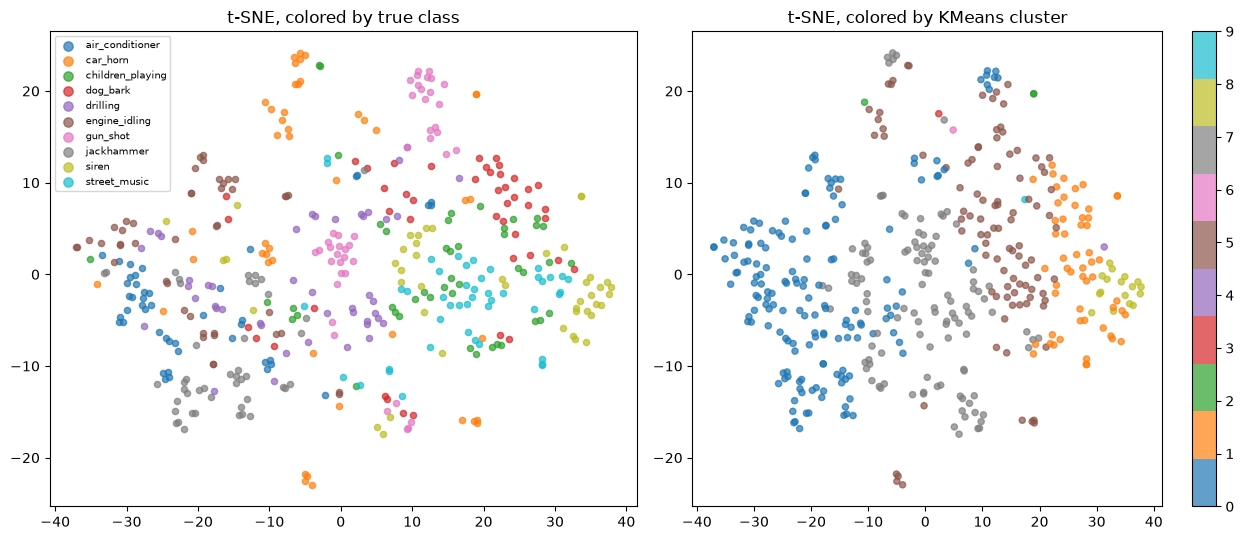

In [5]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, random_state = 42, perplexity = 25, init = 'pca')
X_2d = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5))
for i, cls in enumerate(classes):
    mask = y == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s = 20, label = cls, alpha = 0.7)
axes[0].set_title('t-SNE, colored by true class')
axes[0].legend(fontsize = 7, markerscale = 1.5)

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c = kmeans_labels, cmap = 'tab10', s = 20, alpha = 0.7)
axes[1].set_title('t-SNE, colored by KMeans cluster')
plt.colorbar(sc, ax = axes[1])

plt.tight_layout()
plt.savefig('outputs/clustering_tsne.png', dpi = 120)
plt.show()

Unlike the random forest's 74.4% supervised accuracy, unsupervised
clustering only weakly recovers the real classes here (adjusted Rand
index 0.10 for KMeans, 0.11 for GMM against the true labels, and only
0.29 agreement between the two clustering methods themselves). Several
KMeans clusters collapse to a single point, MFCC profiles for distinct
classes like `car_horn` and `siren` clearly overlap enough in raw
feature space that unsupervised methods can't cleanly separate them
without ever seeing a label, even though a supervised model, given
labels to learn from, does substantially better. This is a real,
honest contrast: labeled supervision is doing a lot of work here that
feature similarity alone can't replace.